# Team Negotiation

One negotiating party is replaced by a private **team of three open-weight models**
that, on every turn, **draft** a move independently, **discuss** it for two rounds,
and select a single move by **Borda vote** before replying to the opponent. The
opponent is always an ordinary single agent. Two compositions are studied on the
**small tier (12–14B: Gemma-3-12B-IT, Ministral-3-14B, Qwen3-14B)**:

- **Homogeneous** — three copies of one model, played against a single agent of the
  same model.
- **Heterogeneous** — one Gemma, one Ministral and one Qwen, played against each
  single model in turn.

The team plays both seats: as first mover (**P1**) and as responder (**P2**). Each
team move costs $N(2+R)+1 = 13$ model calls against the single agent's one, so the
deliberation has to buy a real improvement to be worth it.

**Two questions drive the analysis:** does team deliberation negotiate better than a
single agent, and does heterogeneity matter? The natural reference is the single
agent itself, so every team result is read against a **matched single-agent
baseline** (defined below).

### Metrics

Following Chapter 3 and NegotiationArena:

- **Win Rate** — share of *completed* games in which the focal party obtained a
  strictly higher payoff than the opponent; **ties are excluded** from the
  denominator. Reported with Wilson 95% intervals.
- **Average Payoff** — game-specific: BuySell surplus (price$-$cost for the seller,
  value$-$price for the buyer), Trading net resource-value change (final$-$initial),
  Ultimatum dollars retained. Reported with percentile-bootstrap 95% intervals.
- **Completion Rate** — share of games that reach a valid terminal state. Open-weight
  models fail by emitting unparsable moves; the team runs with **no parse-retry**, so
  this is a genuine cost of the longer pipeline.

### Baseline (matched per team type)

The team's opponent is itself a single agent, so the head-to-head win rate already
compares a team to a single agent. To control for opponent strength and seat we also
match each team cell to a single agent **in the same seat against the same opponent**:

- **Homogeneous team of model $M$** vs the **same-model self-play** baseline
  ($M$ vs $M$, default×default) — holds model, opponent and seat fixed, so only
  team-vs-single differs. This is the cleanest deliberation A/B.
- **Heterogeneous team** vs the **pool of single agents facing the same opponent** in
  the same seat (the two cross-play opponents plus the opponent's own self-play).

All baselines are taken at `max_retries=0`, matching the team's condition. The
homogeneous baseline shares the opponent's model by construction, a confound we return
to when comparing compositions.

In [1]:
import sys, os, json, glob, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt


def find_repo_root():
    starts = [Path.cwd()]
    if "__file__" in globals():
        starts.append(Path(__file__).resolve().parent)
    for start in starts:
        for c in (start, *start.parents):
            if (c / ".logs").exists() and (c / "configs").exists() and (c / "_notebooks").exists():
                return c
    raise FileNotFoundError("repo root not found")


ROOT_DIR = find_repo_root()
sys.path.insert(0, str(ROOT_DIR))
sys.path.insert(0, str(ROOT_DIR / "_notebooks" / "oss" / "style"))
warnings.filterwarnings("ignore")

import seaborn as sns
import style
from style import wilson_ci, bootstrap_ci, errbars_from_ci

# Publication design system + sans-serif "report" skin (matches 1_cross_play_benchmark).
style.apply_thesis_style()
matplotlib.rcParams["axes.prop_cycle"] = matplotlib.cycler(color=sns.color_palette("colorblind", 4).as_hex())
matplotlib.rcParams["font.family"] = "sans-serif"
matplotlib.rcParams["font.sans-serif"] = ["Open Sans", "Noto Sans", "Liberation Sans", "DejaVu Sans"]
matplotlib.rcParams["axes.edgecolor"] = "#8A8880"
matplotlib.rcParams["axes.labelcolor"] = "#3D3C38"
matplotlib.rcParams["xtick.color"] = matplotlib.rcParams["ytick.color"] = "#3D3C38"
matplotlib.rcParams["grid.color"] = "#EAEDF0"
matplotlib.rcParams["grid.alpha"] = 0.9
matplotlib.rcParams["axes.titlesize"] = 11
matplotlib.rcParams["axes.titlecolor"] = "#3D3C38"
matplotlib.rcParams["axes.grid.axis"] = "y"
matplotlib.rcParams["legend.frameon"] = False
FULL_WIDTH, HALF_WIDTH = style.FULL_WIDTH, style.HALF_WIDTH

LOGS_ROOT = str(ROOT_DIR / ".logs")
SIZE = "small"
NOTEBOOK_NAME = "4_team_negotiation"
FIG_DIR = ROOT_DIR / "_notebooks" / "oss" / "figures" / NOTEBOOK_NAME
FIG_DIR.mkdir(parents=True, exist_ok=True)


def save_plot(fig, slug):
    # Save without a whole-figure title; the LaTeX caption supplies it.
    sup = getattr(fig, "_suptitle", None)
    hidden = []
    if sup is not None and sup.get_text():
        sup.set_visible(False); hidden.append(sup)
    fig.savefig(FIG_DIR / f"{slug}.png", dpi=300, bbox_inches="tight")
    for a in hidden:
        a.set_visible(True)


GAMES = ["trading", "ultimatum", "buysell"]
GAME_LABEL = {"trading": "Trading", "ultimatum": "Ultimatum", "buysell": "BuySell"}
FAMILIES = ["gemma", "qwen", "ministral"]
FAM_LABEL = {"gemma": "Gemma", "qwen": "Qwen", "ministral": "Mistral"}
PAYOFF_BOUNDS = {"trading": (-30, 30), "ultimatum": (0, 100), "buysell": (-40, 60)}

# Composition / seat palette on the thesis colours.
COL_SINGLE = style.STRATEGY_COLORS["Default"]        # gray
COL_HOMO = style.STRATEGY_COLORS["Team (homo)"]      # orange
COL_HETERO = style.STRATEGY_COLORS["Team (hetero)"]  # green
SEAT_COLORS = {"P1": "#0173b2", "P2": "#de8f05"}
GAME_COLORS = {"trading": "#0173b2", "ultimatum": "#de8f05", "buysell": "#029e73"}
VAR_MARKER = {"homo": "o", "hetero": "^"}

In [2]:
def clean_name(full_id):
    name = full_id.split("/")[-1]
    for s in ("-Instruct", "-instruct"):
        name = name.replace(s, "")
    return name


def resource_value(res):
    return sum(res["_value"].values())


def model_family(name):
    n = name.lower()
    for fam in FAMILIES:
        if fam in n:
            return fam
    return "ministral" if "mistral" in n else n


def _load_run(path, game):
    # Per-game payoff + validity. ONE function for every source (team and baselines)
    # so team and baseline payoffs are always computed identically.
    with open(path) as f:
        data = json.load(f)
    states, players = data["game_state"], data["players"]
    last = states[-1]
    completed = last.get("current_iteration") == "END"
    out = dict(
        m1=clean_name(players[0].get("model_id", players[0].get("model", "?"))),
        m2=clean_name(players[1].get("model_id", players[1].get("model", "?"))),
        cls1=players[0].get("class"), cls2=players[1].get("class"),
        completed=completed, payoff_1=np.nan, payoff_2=np.nan, deal=False,
    )
    if not completed:
        return out
    s = last.get("summary")
    if s is None:
        out["completed"] = False
        return out
    deal = str(s.get("final_response")) == "ACCEPT"
    if game == "trading":
        ini, fin = s["initial_resources"], s["final_resources"]
        p1 = resource_value(fin[0]) - resource_value(ini[0])
        p2 = resource_value(fin[1]) - resource_value(ini[1])
    elif game == "ultimatum":
        p1 = resource_value(s["player_outcome"][0])
        p2 = resource_value(s["player_outcome"][1])
    else:  # buysell -> player_outcome is [seller, buyer] surplus
        o1, o2 = s["player_outcome"]
        try:
            p1, p2 = float(o1), float(o2)
        except (TypeError, ValueError):
            p1 = p2 = np.nan
    if not deal:
        p1 = p2 = 0.0
    out.update(payoff_1=p1, payoff_2=p2, deal=deal)
    return out


def payoff_valid(game, p1, p2):
    lo, hi = PAYOFF_BOUNDS[game]
    return bool(np.isfinite(p1) and np.isfinite(p2) and lo <= p1 <= hi and lo <= p2 <= hi)


def focal_view(seat, game, r):
    # (focal_payoff, opp_payoff, valid, win); win is NaN on tie / invalid / incomplete.
    if not r["completed"]:
        return np.nan, np.nan, False, np.nan
    p1, p2 = r["payoff_1"], r["payoff_2"]
    valid = payoff_valid(game, p1, p2)
    fp, op = (p1, p2) if seat == "P1" else (p2, p1)
    if not valid or not np.isfinite(fp):
        win = np.nan
    elif fp > op:
        win = 1.0
    elif fp < op:
        win = 0.0
    else:
        win = np.nan
    return fp, op, valid, win

In [3]:
def _states(root):
    return glob.glob(os.path.join(root, "**", "game_state.json"), recursive=True)


def _parse_p1(folder):       # team_{members}_vs_{opp}
    for part in folder.split(os.sep):
        if part.startswith("team_") and "_vs_" in part:
            team_raw, opp_raw = part[len("team_"):].rsplit("_vs_", 1)
            return team_raw, opp_raw
    return None, None


def _parse_p2(folder):       # {opp}_vs_team_{members}
    for part in folder.split(os.sep):
        if "_vs_team_" in part:
            opp_raw, team_raw = part.split("_vs_team_", 1)
            return team_raw, opp_raw
    return None, None


rows = []
# Team rows, both seats (P1 = *_v1, P2 = *_v1_p2).
for game in GAMES:
    for variant in ("homo", "hetero"):
        for seat, suffix, parser in (("P1", "", _parse_p1), ("P2", "_p2", _parse_p2)):
            root = os.path.join(LOGS_ROOT, "negotiation_team",
                                f"{game}_negotiation_team_{variant}_v1{suffix}", SIZE)
            for path in _states(root):
                team_raw, opp_raw = parser(os.path.dirname(path))
                if opp_raw is None:
                    continue
                r = _load_run(path, game)
                fp, op, valid, win = focal_view(seat, game, r)
                base = "trio" if variant == "hetero" else model_family(clean_name(team_raw.split("_x3")[0]))
                rows.append(dict(source="team", game=game, strategy=f"Team ({variant})",
                                 variant=variant, team_base=base,
                                 opponent=model_family(clean_name(opp_raw)), seat=seat,
                                 focal_payoff=fp, opp_payoff=op, completed=r["completed"],
                                 valid=valid, win=win))


def _add_baseline(game, root, kind, cond=None):
    for path in _states(root):
        if cond and cond not in path:
            continue
        r = _load_run(path, game)
        for seat in ("P1", "P2"):
            fp, op, valid, win = focal_view(seat, game, r)
            fm = r["m1"] if seat == "P1" else r["m2"]
            om = r["m2"] if seat == "P1" else r["m1"]
            rows.append(dict(source="baseline", game=game, strategy="Single",
                             variant=None, team_base=None,
                             focal_model=model_family(fm), opponent=model_family(om), seat=seat,
                             focal_payoff=fp, opp_payoff=op, completed=r["completed"],
                             valid=valid, win=win, baseline_kind=kind))


for game in GAMES:
    _add_baseline(game, os.path.join(LOGS_ROOT, "section_one", f"{game}_section_one", "no_retries", SIZE),
                  "crossplay")
    _add_baseline(game, os.path.join(LOGS_ROOT, "self_refine", f"{game}_self_refine_v1", SIZE),
                  "selfplay", cond="defaultP1_defaultP2")

DF = pd.DataFrame(rows)
DF["game"] = pd.Categorical(DF["game"], categories=GAMES, ordered=True)
TEAM = DF[DF.source == "team"].copy()
BASE = DF[DF.source == "baseline"].copy()

print("Team runs per game x variant x seat (30 per matchup, 3 matchups -> 90):")
print(TEAM.groupby(["game", "variant", "seat"]).size().unstack("seat"))
print("\nBaseline runs (long, one row per seat) per game x kind:")
print(BASE.groupby(["game", "baseline_kind"]).size().unstack("baseline_kind"))

Team runs per game x variant x seat (30 per matchup, 3 matchups -> 90):
seat               P1  P2
game      variant        
trading   hetero   90  90
          homo     90  90
ultimatum hetero   90  90
          homo     90  90
buysell   hetero   90  90
          homo     90  90

Baseline runs (long, one row per seat) per game x kind:
baseline_kind  crossplay  selfplay
game                              
trading              360       180
ultimatum            360       180
buysell              360       180


In [4]:
def wr_ci(s):
    # ties-excluded win rate + Wilson 95% interval + decisive-game count.
    w = s.dropna()
    k, n = int((w == 1).sum()), len(w)
    rate = k / n if n else np.nan
    lo, hi = wilson_ci(k, n)
    return rate, lo, hi, n


def mean_payoff_ci(s):
    x = s.dropna().values
    if len(x) == 0:
        return np.nan, np.nan, np.nan
    lo, hi = bootstrap_ci(x)
    return float(np.mean(x)), lo, hi


def matched_single(game, seat, variant, opponent):
    if variant == "homo":          # same-model self-play, same seat
        return BASE[(BASE.game == game) & (BASE.seat == seat) & (BASE.baseline_kind == "selfplay")
                    & (BASE.focal_model == opponent) & (BASE.opponent == opponent)]
    return BASE[(BASE.game == game) & (BASE.seat == seat) & (BASE.opponent == opponent)]


# 36 matched team-vs-single cells (game x seat x variant x opponent).
recs = []
for game in GAMES:
    for seat in ("P1", "P2"):
        for variant in ("homo", "hetero"):
            tt = TEAM[(TEAM.game == game) & (TEAM.seat == seat) & (TEAM.variant == variant)]
            for opp in sorted(tt["opponent"].unique()):
                ts = tt[tt.opponent == opp]
                bs = matched_single(game, seat, variant, opp)
                tr, tlo, thi, tn = wr_ci(ts["win"])
                br, blo, bhi, bn = wr_ci(bs["win"])
                tp, _, _ = mean_payoff_ci(ts.loc[ts.valid, "focal_payoff"])
                bp, _, _ = mean_payoff_ci(bs.loc[bs.valid, "focal_payoff"])
                rel = "team>single" if tlo > bhi else "team<single" if thi < blo else "overlap"
                recs.append(dict(game=game, seat=seat, variant=variant, opponent=opp,
                                 team_wr=tr, single_wr=br, team_pay=tp, single_pay=bp,
                                 tn=tn, bn=bn, rel=rel))
CMP = pd.DataFrame(recs)

# 18 homogeneous-vs-heterogeneous cells against a common opponent + seat.
hh = []
for game in GAMES:
    for seat in ("P1", "P2"):
        for opp in FAMILIES:
            ho = TEAM[(TEAM.game == game) & (TEAM.seat == seat) & (TEAM.variant == "homo") & (TEAM.opponent == opp)]
            he = TEAM[(TEAM.game == game) & (TEAM.seat == seat) & (TEAM.variant == "hetero") & (TEAM.opponent == opp)]
            hr, hlo, hhi, hn = wr_ci(ho["win"])
            er, elo, ehi, en = wr_ci(he["win"])
            rel = "overlap"
            if hn and en:
                rel = "homo>hetero" if hlo > ehi else "hetero>homo" if elo > hhi else "overlap"
            hh.append(dict(game=game, seat=seat, opponent=opp, homo_wr=hr, hetero_wr=er,
                           hn=hn, en=en, rel=rel))
HH = pd.DataFrame(hh)

print("Team-vs-single matched cells (win-rate CI relationship):")
print(CMP["rel"].value_counts().to_string())
print(f"\nmean(team - single) win rate = {(CMP.team_wr - CMP.single_wr).mean():+.3f}")
print(f"mean(team - single) payoff   = {(CMP.team_pay - CMP.single_pay).mean():+.3f}")
print("\nHomo-vs-hetero common-opponent cells:")
print(HH["rel"].value_counts().to_string())
print(f"mean(hetero - homo) win rate = {(HH.hetero_wr - HH.homo_wr).mean():+.3f}")

Team-vs-single matched cells (win-rate CI relationship):
rel
overlap    36

mean(team - single) win rate = +0.037
mean(team - single) payoff   = +2.452

Homo-vs-hetero common-opponent cells:
rel
overlap        17
homo>hetero     1
mean(hetero - homo) win rate = -0.005


## Phase 1 — open exploration

Before fixing on any structure, a first look at win rates against the single agent,
the gap between compositions, and where games fall apart.

In [5]:
# Head-to-head: team win rate against its single-agent opponent, by game x seat x variant.
ht = (TEAM.groupby(["game", "seat", "variant"])
      .apply(lambda d: pd.Series(dict(zip(["win_rate", "lo", "hi", "n"], wr_ci(d["win"])))))
      .reset_index())
print("Head-to-head team win rate (ties excluded):")
print(ht.assign(win_rate=ht.win_rate.round(2), lo=ht.lo.round(2), hi=ht.hi.round(2),
                n=ht.n.astype(int)).to_string(index=False))

print("\nCompletion rate (max_retries = 0):")
tc = TEAM.groupby(["game", "seat"])["completed"].mean().round(3).unstack("seat")
b1 = BASE[BASE.seat == "P1"]
bc = b1.groupby(["game", "baseline_kind"])["completed"].mean().round(3).unstack("baseline_kind")
print(pd.concat([tc.add_prefix("team_"), bc.add_prefix("single_")], axis=1).to_string())

Head-to-head team win rate (ties excluded):
     game seat variant  win_rate   lo   hi  n
  trading   P1  hetero      0.30 0.21 0.41 76
  trading   P1    homo      0.31 0.21 0.43 65
  trading   P2  hetero      0.85 0.75 0.92 67
  trading   P2    homo      0.88 0.77 0.94 64
ultimatum   P1  hetero      0.93 0.84 0.97 69
ultimatum   P1    homo      0.95 0.87 0.98 65
ultimatum   P2  hetero      0.01 0.00 0.08 70
ultimatum   P2    homo      0.11 0.05 0.20 66
  buysell   P1  hetero      0.20 0.12 0.32 55
  buysell   P1    homo      0.09 0.04 0.19 64
  buysell   P2  hetero      0.96 0.88 0.99 72
  buysell   P2    homo      0.93 0.85 0.97 73

Completion rate (max_retries = 0):
           team_P1  team_P2  single_crossplay  single_selfplay
game                                                          
trading      0.889    0.944             0.956            0.856
ultimatum    0.972    0.967             1.000            0.889
buysell      0.867    0.950             1.000            0.933


### What stands out

- **The seat decides the game.** As responder (**P2**) the team wins Trading
  (≈0.85–0.88) and BuySell (≈0.93–0.96); as proposer (**P1**) it wins Ultimatum
  (≈0.93–0.95). Move it to the other seat and it loses just as decisively — Ultimatum
  P2 ≈0.01–0.11, BuySell P1 ≈0.09–0.20, Trading P1 ≈0.30. This is the same
  first/second-mover advantage single agents show on these games; the team does not
  escape it.

- **Homogeneous and heterogeneous teams look interchangeable** at this glance: their
  win rates sit on top of each other in every game and seat.

- **The team neither dominates nor collapses against its opponent.** Where it wins it
  wins by the seat; where it loses it loses by the seat. Nothing yet suggests three
  deliberating models beat one.

- **Completion is not free.** The team finishes 0.87–0.97 of games — below the
  cross-play single-agent ceiling (0.96–1.00) and close to the same-model self-play
  baseline (0.86–0.93). The thirteen-call pipeline with no parse-retry has more places
  to fail.

These observations set the three questions pursued below: is the team better than a
matched single agent, does composition matter, and what does the deliberation itself
look like.

## Phase 2 — structured analysis

### 1. Completion rate

Completion is reported first because every later metric is conditional on it, and
because the team's longer pipeline is a plausible place to lose games. Bars are Wilson
95% intervals; baselines are the matched single agents at the same `max_retries = 0`.

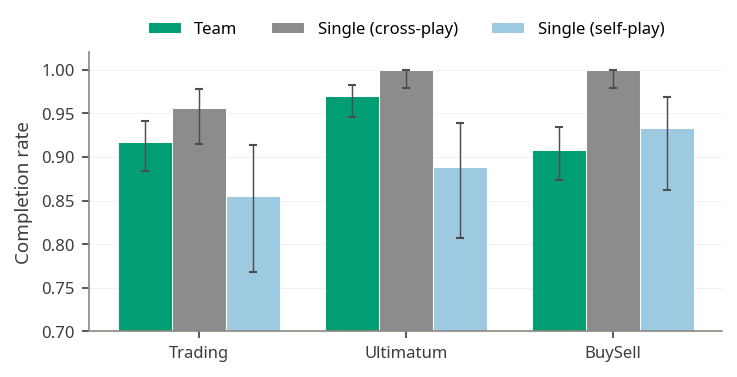

In [6]:
def comp_ci(s):
    k, n = int(s.sum()), len(s)
    lo, hi = wilson_ci(k, n)
    return k / n if n else np.nan, lo, hi


series = [("Team", TEAM, None), ("Single (cross-play)", b1, "crossplay"),
          ("Single (self-play)", b1, "selfplay")]
colors = [COL_HETERO, COL_SINGLE, "#9ecae1"]
fig, ax = plt.subplots(figsize=(FULL_WIDTH * 0.8, 2.4))
x = np.arange(len(GAMES)); w = 0.26
for i, (label, frame, kind) in enumerate(series):
    rates, cis = [], []
    for g in GAMES:
        sub = frame[frame.game == g]
        if kind:
            sub = sub[sub.baseline_kind == kind]
        r, lo, hi = comp_ci(sub["completed"])
        rates.append(r); cis.append((lo, hi))
    pos = x + (i - 1) * w
    ax.bar(pos, rates, w, label=label, color=colors[i], edgecolor="white", linewidth=0.5)
    ax.errorbar(pos, rates, yerr=errbars_from_ci(rates, cis), fmt="none", ecolor="0.3", lw=0.7, capsize=2)
ax.set_xticks(x, [GAME_LABEL[g] for g in GAMES])
ax.set_ylim(0.7, 1.02); ax.set_ylabel("Completion rate")
ax.legend(loc="lower center", ncols=3, bbox_to_anchor=(0.5, 1.0))
save_plot(fig, "completion_rate")
plt.show()

At `max_retries = 0` no condition reaches the ceiling on the small tier. The team
completes slightly **below the cross-play single agent** in Trading and BuySell, and
tracks the same-model self-play baseline. Pooling three copies of one model (or running
a model against itself) concentrates the same format fragility on both sides, and the
team's extra reply-rewriting step adds another point of failure. The deliberation does
not improve robustness; if anything it costs a few games relative to a single
cross-play agent.

### 2. Does deliberation beat a single agent?

Win rate is the direct measure of who comes out ahead, so it leads here. The first
figure isolates the structural effect; the second puts the team next to the matched
single agent.

**Seat, not deliberation, sets the result.** Team win rate by game and seat,
pooled over composition and opponent (Wilson 95% intervals; dashed line is parity).

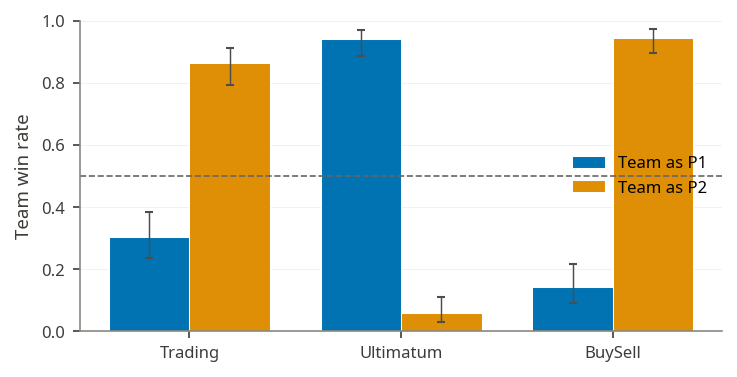

In [7]:
fig, ax = plt.subplots(figsize=(FULL_WIDTH * 0.8, 2.4))
x = np.arange(len(GAMES)); w = 0.38
for i, seat in enumerate(["P1", "P2"]):
    rates, cis = [], []
    for g in GAMES:
        r, lo, hi, _ = wr_ci(TEAM[(TEAM.game == g) & (TEAM.seat == seat)]["win"])
        rates.append(r); cis.append((lo, hi))
    pos = x + (i - 0.5) * w
    ax.bar(pos, rates, w, label=f"Team as {seat}", color=SEAT_COLORS[seat],
           edgecolor="white", linewidth=0.5)
    ax.errorbar(pos, rates, yerr=errbars_from_ci(rates, cis), fmt="none", ecolor="0.3", lw=0.7, capsize=2)
ax.axhline(0.5, ls="--", color="0.4", lw=0.8)
ax.set_xticks(x, [GAME_LABEL[g] for g in GAMES])
ax.set_ylim(0, 1); ax.set_ylabel("Team win rate")
ax.legend(loc="center right")
save_plot(fig, "seat_dominates")
plt.show()

The team wins almost every Ultimatum from the proposer's seat and almost none
from the responder's; in Trading and BuySell the order reverses, the responder winning.
The advantaged seat carries the team to 0.85–0.95 and the disadvantaged seat sinks it
to near zero — the identical pattern single agents show. Whatever deliberation does, it
does not change which seat wins.

**Against the matched single agent the team barely moves.** Each point is one of
the 36 (game × seat × composition × opponent) cells: team win rate versus the win rate
of a single agent in the same seat against the same opponent. Points on the diagonal
mean no difference.

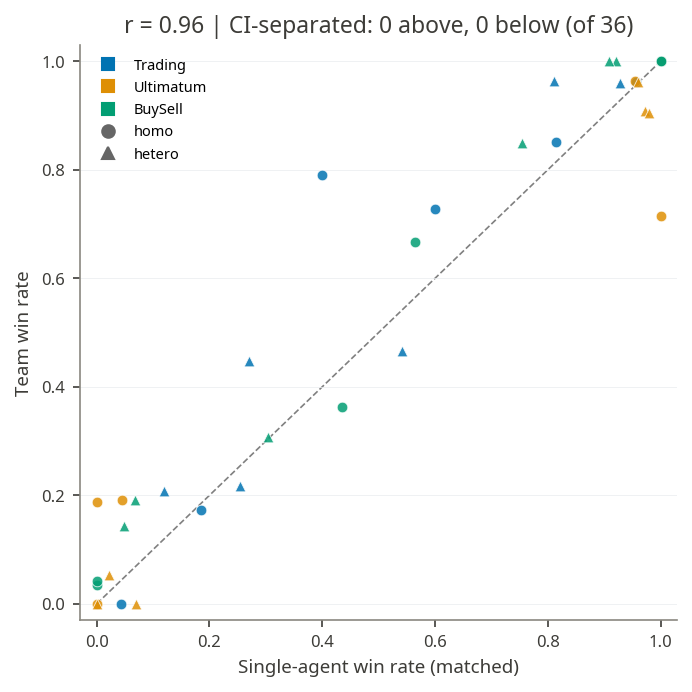

mean(team - single) win rate = +0.037 (median +0.020)


In [8]:
fig, ax = plt.subplots(figsize=(HALF_WIDTH * 1.5, HALF_WIDTH * 1.5))
ax.plot([0, 1], [0, 1], ls="--", color="0.5", lw=0.8, zorder=0)
for _, r in CMP.iterrows():
    ax.scatter(r.single_wr, r.team_wr, s=26, color=GAME_COLORS[r.game],
               marker=VAR_MARKER[r.variant], alpha=0.85, edgecolor="white", linewidth=0.4)
from matplotlib.lines import Line2D
leg_game = [Line2D([], [], marker="s", ls="", color=GAME_COLORS[g], label=GAME_LABEL[g]) for g in GAMES]
leg_var = [Line2D([], [], marker=VAR_MARKER[v], ls="", color="0.4", label=v) for v in ("homo", "hetero")]
ax.legend(handles=leg_game + leg_var, loc="upper left", fontsize=7, ncols=1)
ax.set_xlim(-0.03, 1.03); ax.set_ylim(-0.03, 1.03)
ax.set_xlabel("Single-agent win rate (matched)"); ax.set_ylabel("Team win rate")
r_pearson = CMP[["team_wr", "single_wr"]].corr().iloc[0, 1]
n_above = (CMP.rel == "team>single").sum(); n_below = (CMP.rel == "team<single").sum()
ax.set_title(f"r = {r_pearson:.2f} | CI-separated: {n_above} above, {n_below} below (of {len(CMP)})")
save_plot(fig, "team_vs_single_winrate")
plt.show()
print(f"mean(team - single) win rate = {(CMP.team_wr - CMP.single_wr).mean():+.3f} "
      f"(median {(CMP.team_wr - CMP.single_wr).median():+.3f})")

The points lie on the diagonal: team win rate tracks the matched single agent
almost exactly (r ≈ 0.96). **Not one of the 36 cells shows a confidence-interval-
separated difference** in either direction. The mean lift from running three
deliberating models instead of one is +0.04 in win rate — within noise, and small
relative to the per-cell intervals. The team inherits the single agent's win rate
against each opponent rather than improving on it.

The same holds for payoff margins, which win rate ignores. Mean focal payoff,
team versus matched single agent, one point per cell.

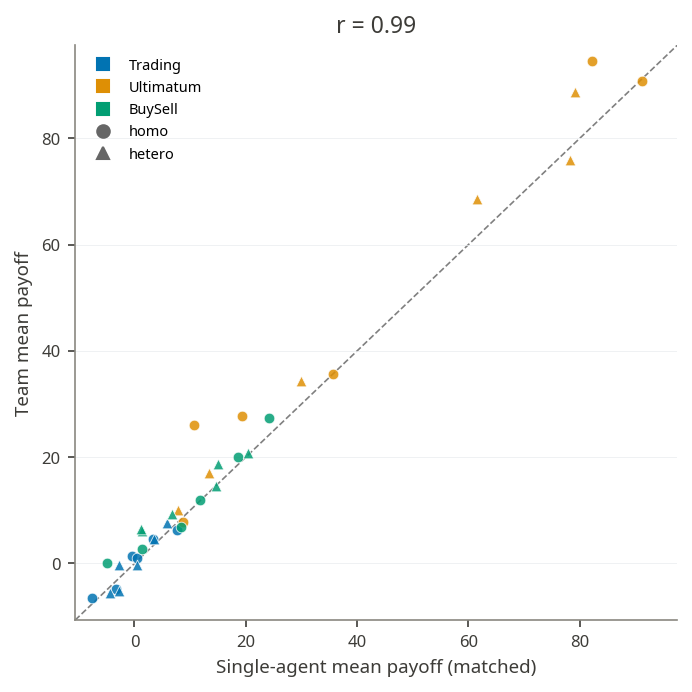

mean(team - single) payoff = +2.45


In [9]:
fig, ax = plt.subplots(figsize=(HALF_WIDTH * 1.5, HALF_WIDTH * 1.5))
lo = min(CMP.single_pay.min(), CMP.team_pay.min()) - 3
hi = max(CMP.single_pay.max(), CMP.team_pay.max()) + 3
ax.plot([lo, hi], [lo, hi], ls="--", color="0.5", lw=0.8, zorder=0)
for _, r in CMP.iterrows():
    ax.scatter(r.single_pay, r.team_pay, s=26, color=GAME_COLORS[r.game],
               marker=VAR_MARKER[r.variant], alpha=0.85, edgecolor="white", linewidth=0.4)
ax.legend(handles=leg_game + leg_var, loc="upper left", fontsize=7)
ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
ax.set_xlabel("Single-agent mean payoff (matched)"); ax.set_ylabel("Team mean payoff")
ax.set_title(f"r = {CMP[['team_pay','single_pay']].corr().iloc[0,1]:.2f}")
save_plot(fig, "team_vs_single_payoff")
plt.show()
print(f"mean(team - single) payoff = {(CMP.team_pay - CMP.single_pay).mean():+.2f}")

Payoff tells the same story even more tightly (r ≈ 0.99): the team earns what a
single agent earns in that seat. The average payoff difference of +2.5 is small against
the games' ranges (Ultimatum 0–100, BuySell ±60, Trading ±30) and is not separated from
zero in any cell. On both metrics, deliberation does not buy a better outcome.

### 3. Does heterogeneity matter?

Holding the opponent and seat fixed isolates composition: a homogeneous team and the
heterogeneous trio face the same single agent in the same seat. Each point is one of the
18 such cells.

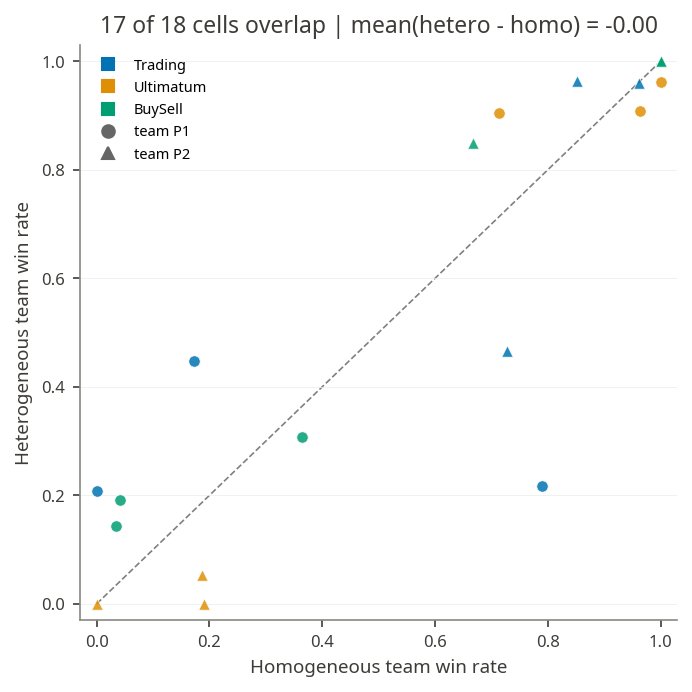

In [10]:
fig, ax = plt.subplots(figsize=(HALF_WIDTH * 1.5, HALF_WIDTH * 1.5))
ax.plot([0, 1], [0, 1], ls="--", color="0.5", lw=0.8, zorder=0)
for _, r in HH.iterrows():
    ax.scatter(r.homo_wr, r.hetero_wr, s=30, color=GAME_COLORS[r.game],
               marker="o" if r.seat == "P1" else "^", alpha=0.85, edgecolor="white", linewidth=0.4)
leg_seat = [Line2D([], [], marker="o", ls="", color="0.4", label="team P1"),
            Line2D([], [], marker="^", ls="", color="0.4", label="team P2")]
ax.legend(handles=leg_game + leg_seat, loc="upper left", fontsize=7)
ax.set_xlim(-0.03, 1.03); ax.set_ylim(-0.03, 1.03)
ax.set_xlabel("Homogeneous team win rate"); ax.set_ylabel("Heterogeneous team win rate")
n_ov = (HH.rel == "overlap").sum()
ax.set_title(f"{n_ov} of {len(HH)} cells overlap | mean(hetero - homo) = {(HH.hetero_wr - HH.homo_wr).mean():+.2f}")
save_plot(fig, "homo_vs_hetero_winrate")
plt.show()

The compositions are interchangeable: 17 of 18 cells have overlapping intervals
and the average heterogeneous-minus-homogeneous win rate is ≈0. The single exception is
Trading as P1 against Qwen, where the homogeneous (all-Qwen) team scores higher — but
that cell is exactly the confound to be wary of: the homogeneous team *is* the opponent
model, so a high score there reflects Qwen's strength on both sides, not an effect of
homogeneity. Once opponent and seat are held fixed, mixing model families changes
nothing measurable in the outcome.

### 4. Inside the deliberation

If heterogeneity has no effect on outcomes, the deliberation traces show why: they let
us check whether mixed teams at least *argue* differently. Two trace measures are
informative — **unanimity**, the share of turns where all three members rank the chosen
move first, and the **Borda margin**, the normalised gap between the top two candidates,
which measures how decisively the vote settles. A high value on either means the members
largely agree.

1288 deliberation turns
         unanimity  margin
variant                   
hetero       0.620   0.446
homo         0.639   0.438


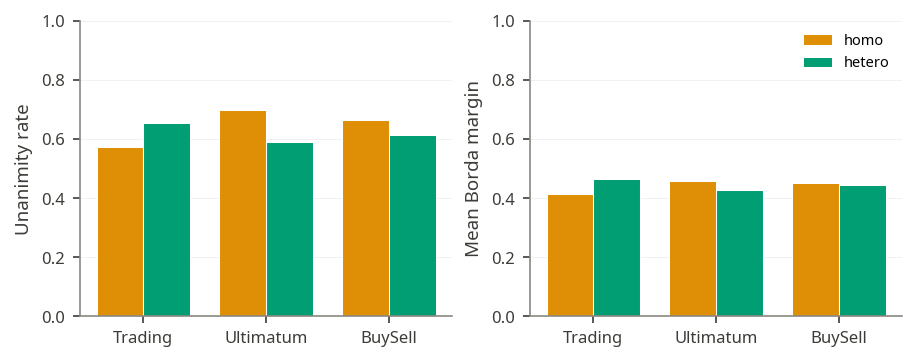

In [11]:
proc = []
for game in GAMES:
    for variant in ("homo", "hetero"):
        for suffix, seat in (("", "P1"), ("_p2", "P2")):
            root = os.path.join(LOGS_ROOT, "negotiation_team",
                                f"{game}_negotiation_team_{variant}_v1{suffix}", SIZE)
            for tp in glob.glob(os.path.join(root, "**", "deliberation_trace_*.json"), recursive=True):
                tr = json.load(open(tp))
                rk = [r for r in tr.get("rankings", []) if r]
                winner = tr.get("winner_index", 0)
                sc = sorted(tr.get("borda_scores", []), reverse=True)
                proc.append(dict(game=game, variant=variant, seat=seat,
                                 unanimous=bool(rk) and all(r[0] == winner for r in rk),
                                 margin=(sc[0] - sc[1]) / sc[0] if len(sc) > 1 and sc[0] else np.nan))
PROC = pd.DataFrame(proc)
print(f"{len(PROC)} deliberation turns")
print(PROC.groupby("variant").agg(unanimity=("unanimous", "mean"), margin=("margin", "mean")).round(3))

fig, axes = plt.subplots(1, 2, figsize=(FULL_WIDTH, 2.3))
for ax, (metric, label) in zip(axes, [("unanimous", "Unanimity rate"), ("margin", "Mean Borda margin")]):
    x = np.arange(len(GAMES)); w = 0.38
    for i, variant in enumerate(["homo", "hetero"]):
        vals = [PROC[(PROC.game == g) & (PROC.variant == variant)][metric].mean() for g in GAMES]
        ax.bar(x + (i - 0.5) * w, vals, w, label=variant,
               color=COL_HOMO if variant == "homo" else COL_HETERO, edgecolor="white", linewidth=0.5)
    ax.set_xticks(x, [GAME_LABEL[g] for g in GAMES]); ax.set_ylim(0, 1); ax.set_ylabel(label)
axes[1].legend(loc="upper right", fontsize=7)
save_plot(fig, "deliberation_consensus")
plt.show()

Mixed teams do not deliberate more contentiously than copies of one model. Across
≈1,300 turns the heterogeneous and homogeneous teams reach the same level of internal
agreement — unanimity ≈0.62 versus ≈0.64, Borda margin ≈0.45 for both — and the small
per-game differences point in inconsistent directions. The members of a mixed team
converge on a winning move about as readily as identical members do. The deliberation
machinery runs the same way regardless of composition, which is consistent with the
absence of any composition effect on outcomes.

### 5. Conclusions

1. **Seat governs outcomes, not deliberation.** The team wins from the structurally
   advantaged seat (responder in Trading and BuySell, proposer in Ultimatum) and loses
   from the other, exactly as single agents do; its win rate tracks the matched single
   agent at r ≈ 0.96.

2. **A deliberating team does not beat a single agent.** Across 36 seat- and
   opponent-matched cells, none shows a confidence-interval-separated win-rate or payoff
   difference. The average effect of replacing one agent with three is +0.04 in win rate
   and +2.5 in payoff — within noise.

3. **Heterogeneity does not matter.** Homogeneous and heterogeneous teams perform within
   each other's intervals in 17 of 18 common-opponent cells (mean difference ≈0), and
   reach near-identical internal consensus (unanimity ≈0.62–0.64, Borda margin ≈0.45).
   Mixing model families changes neither the outcome nor the character of the
   deliberation.

4. **The overhead is not justified on this benchmark.** Each team move costs about
   thirteen model calls against the single agent's one, and completion (0.87–0.97) sits
   below the cross-play single-agent ceiling rather than above it. The team pays a large
   inference cost for no measurable negotiating advantage.

**Caveats.** Homogeneous teams share the opponent's model by construction, so the
homogeneous-versus-heterogeneous comparison partly confounds composition with model
identity. After excluding ties and incomplete games some cells have few decisive games,
widening the intervals. All results are observational two-party games on the small tier;
no causal mechanism is claimed, and the findings need not transfer to other tiers, games
or team sizes.